3.4 Multi-Layer Perception

mnist_starter.py

Batch of images shape: torch.Size([64, 1, 28, 28])
Batch of labels shape: torch.Size([64])
torch.int64
tensor(3)


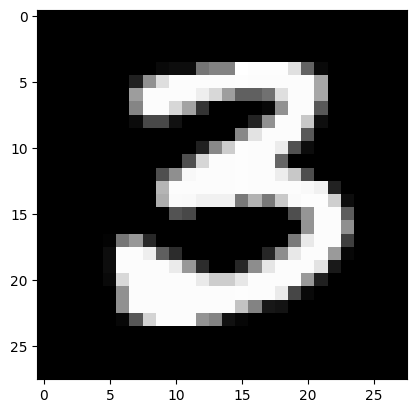

torch.Size([128, 784])
torch.Size([128])
number of parameters:  101770
<class 'torch.nn.modules.loss.CrossEntropyLoss'>
loss value:  2.357675552368164
Step: 937 loss value:  0.1000366061925888
Step: 937 loss value:  0.08670273423194885
Step: 937 loss value:  0.22352468967437744
Step: 937 loss value:  0.04787584766745567
Step: 937 loss value:  0.04058992490172386


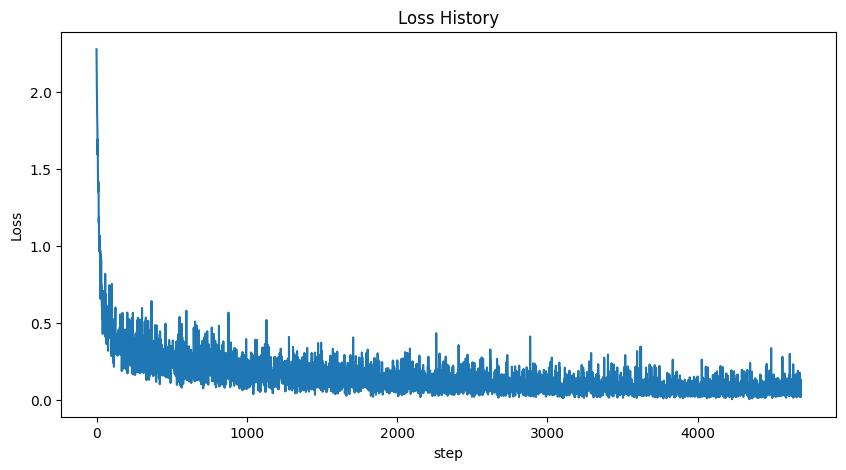

In [42]:
import torch
import torch.nn as nn

from torchvision import datasets, transforms
from matplotlib import pyplot as plt

### Define a transform to normalize the data
transform = transforms.Compose([
    transforms.ToTensor(), # casting everything to be a tensor
    transforms.Normalize((0.1307,), (0.3081,)) # shifts the center or mean of the data. 
]) # the numbers are the mean and standard deviation

''' 
If this were RGB instead

You’d see three values, one per channel:

transforms.Normalize(
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225)
)

'''


### Download and load the training data
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform) 
# download the data, and clean it up.pass a transform to it
# train=True, store only the data used for training
# train=False, store data for testing


# must shuffle just in case if the last parts of training are of the same class.
# shuffle to avoid bias
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
# average 64 batches
# backpropagation
# use less memory, allow a bit of noise to gradients
# allow more frequent weight updates


### Download and load the test data
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False) # no need to shuffle
# batch 1000 because
# only forward passes
# larger batches are faster

# why do we want to separate dataset grabber and loader

### Example: get a batch of training data
images, labels = next(iter(train_loader))
print("Batch of images shape:", images.shape) # torch.Size([64, 1, 28, 28])
# 64 is the batch size
# 1 means grayscale picture.
# 28 is the height
# 28 is the width

print("Batch of labels shape:", labels.shape) # torch.Size([64])
# 64 labels of integers

print(labels.dtype) # torch.int64

print(labels[13])

# pytorch is (C, H, W)
# matplotlib image format is (H, W) or (H, W, C)
plt.imshow(images[13].squeeze(), cmap = 'grey') # squeeze is compress, 
# original = (1, 28, 28)
# squeeze = (28, 28)

plt.show()

class SimpleNN(nn.Module):
    def __init__(self): # constructor of the class
        super(SimpleNN, self).__init__()

        # input layer to hidden layer
        self.l1 = nn.Linear(28*28, 128) # linear transformation
        # inside are the dimensions

        # activation function
        self.relu = nn.ReLU()
        
        # hidden layer to output layer
        self.l2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.reshape(-1, 784) # -1 automatically figures out what it should be
        # no need to remember the batch size

        output1 = self.l1(x)
        input_2 = self.relu(output1)
        output2 = self.l2(input_2)

        return output2



'''
# Attempt: Call a layer 1 on a batch of data and print the output shape
# already have batch of images (from above 'next(iter...' ) 
# two ways
images_flat = torch.flatten(images, start_dim=1)
#images_flat = images.view(images.size(0), -1) # first flatten the images
# Linear does not understand spatial dimensions

output_l1 = mynetwork.l1(images_flat)
print(output_l1.shape)

'''

mynetwork = SimpleNN()
'''
# print(mynetwork.forward(images))
print(mynetwork(images)) # this calls the forward by itself

print(mynetwork(images).shape) # 64, 10
# 64 images, 10 classes

print(mynetwork.parameters()) # <generator object Module.parameters at 0x30ca6f840>
# means it's an iterator object

'''
params = list(mynetwork.parameters()) # list of all the weights and biases
# why is this important?
# we can save the weights once trained to avoid training again

print(params[0].shape) # weight matrix
print(params[1].shape) # bias
# print(params)


# p.numel total num of parameters in a specific layer
# for all layers
# then sum it all up
num_params = sum(p.numel() for p in mynetwork.parameters())
print("number of parameters: ", num_params)

# training


# Todo: 
# Define a loss function
loss = torch.nn.CrossEntropyLoss() # function handle
print(type(loss)) # <class 'torch.nn.modules.loss.CrossEntropyLoss'>

# Evaluate the (untrained) model using the loss function
output = mynetwork(images) # forward pass
loss_value = loss(output, labels) # a single number, the loss value
print("loss value: ", loss_value.item()) # .item() to get the number out of the tensor

# Perform one optim step w
optim = torch.optim.SGD(mynetwork.parameters(), lr = 0.05) # improves losses through small batches
optim.zero_grad() # need to zero out the gradients before each step, otherwise they will accumulate

# optim = torch.optim.Adam() # history of how well it performed in the pervious step, and uses that to adjust the learning rate

# take the gradient
loss_value.backward()
loss_history = []
# perform optimization step
optim.step()

# Todo: write a for loop
# That gets a new batch of data
# Evaluates the ouput of the model on that data
# Calculates the loss
# takes the gradient
# takes the optimizer step
# prints the loss 
# repeats

num_epoch = 5
for epoch in range(num_epoch):
    for step, (images, labels) in enumerate(train_loader):

        output = mynetwork(images)
        loss_value = loss(output, labels)
        loss_history.append(loss_value.item())
        optim.zero_grad()
        loss_value.backward()
        optim.step()
    print("Step:", step ,"loss value: ", loss_value.item())

# create a loss_history line plot

plt.figure(figsize=(10, 5))
plt.plot(loss_history)
plt.xlabel("step")
plt.ylabel("Loss")
plt.title("Loss History")
plt.show()



